# Multimodal Exploration: Skeleton + Synthetic IMU

**Goal**: Evaluate whether adding synthetic inertial data (from 3D skeleton) improves medical action recognition.

## Approach
1. Generate **synthetic accelerometer** data from NTU 3D skeleton joint trajectories
2. Virtual sensors: **right wrist** (joint 11) + **waist** (joint 0) → 6 channels (2×3 axes)
3. Compare:
   - **Skeleton-only**: STGCN++ (centralized, 10 epochs)
   - **Late Fusion**: STGCN++ (256-d) + 1D-CNN (128-d) → FC(384, 10)

## Physics
Synthetic acceleration from discrete 2nd derivative of joint position:

$$a(t) = \frac{p(t+1) - 2p(t) + p(t-1)}{\Delta t^2}$$

Post-processing: Butterworth low-pass filter + Gaussian noise ($\sigma=0.05$)

In [1]:
# @title Setup {display-mode: "form"}
!pip install -q scikit-learn

import os, time, copy, json, math, pickle
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter, defaultdict, OrderedDict
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d

print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
assert torch.cuda.is_available(), "No GPU! Runtime → Change runtime type → T4 GPU"
DEVICE = 'cuda'

PyTorch 2.10.0+cu128  |  CUDA: True
GPU: Tesla T4


In [2]:
# ═══ Multimodal Experiment Config ═══
SEED = 42
NUM_CLASSES = 10
BATCH_SIZE = 64
LR = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
QUICK_EPOCHS = 10

MODEL_KWARGS = dict(base_channels=64, num_stages=6, num_person=2, dropout=0.3)

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.makedirs('outputs', exist_ok=True)

MEDICAL_CLASS_MAP = {42: 0, 41: 1, 43: 2, 44: 3, 45: 4, 46: 5, 47: 6, 8: 7, 7: 8, 58: 9}
MEDICAL_LABELS = [
    'falling', 'staggering', 'touch head', 'touch chest', 'touch back',
    'touch neck', 'nausea', 'standing up', 'sitting down', 'walking towards',
]
print('Config set ✓')

Config set ✓


## 1. Data: 2D Skeleton (HRNet) + 3D Skeleton (Kinect)
Download both datasets — 2D for STGCN++ input, 3D for synthetic IMU generation.

In [3]:
data_dir = 'data/nturgbd'
pkl_path = f'{data_dir}/ntu60_hrnet.pkl'
pkl_3d = f'{data_dir}/ntu60_3danno.pkl'

for url, path in [
    ('https://download.openmmlab.com/mmaction/pyskl/data/nturgbd/ntu60_hrnet.pkl', pkl_path),
    ('https://download.openmmlab.com/mmaction/pyskl/data/nturgbd/ntu60_3danno.pkl', pkl_3d),
]:
    if not os.path.exists(path):
        os.makedirs(data_dir, exist_ok=True)
        !wget -q --show-progress -O {path} {url}
        print(f'Downloaded: {path}')
    else:
        print(f'Already exists: {path}')

with open(pkl_path, 'rb') as f:
    data = pickle.load(f)
with open(pkl_3d, 'rb') as f:
    data_3d = pickle.load(f)

split_info = data['split']
annotations = data['annotations']
ann_3d = data_3d['annotations']

selected = set(MEDICAL_CLASS_MAP.keys())
medical_anns = [a for a in annotations if a['label'] in selected]

# 3D lookup
ann_3d_lookup = {ann['frame_dir']: ann for ann in ann_3d}
medical_3d = [(ann, ann_3d_lookup[ann['frame_dir']])
              for ann in medical_anns if ann['frame_dir'] in ann_3d_lookup]
print(f'Medical 2D annotations: {len(medical_anns)}')
print(f'Medical with 3D data:   {len(medical_3d)}')

data/nturgbd/ntu60_ 100%[===================>] 672.72M  22.3MB/s    in 31s     
Downloaded: data/nturgbd/ntu60_hrnet.pkl
data/nturgbd/ntu60_ 100%[===================>]   1.10G  24.5MB/s    in 43s     
Downloaded: data/nturgbd/ntu60_3danno.pkl
Medical 2D annotations: 9444
Medical with 3D data:   9444


In [4]:
def prenormalize_2d(kp, ks, img_shape=(1080, 1920), threshold=0.01):
    kp = kp.astype(np.float32).copy()
    ks = ks.astype(np.float32)
    kp = np.concatenate([kp, ks[..., None]], axis=-1)
    mask = kp[..., 2] <= threshold
    h, w = img_shape
    kp[..., 0] = (kp[..., 0] - w/2) / (w/2)
    kp[..., 1] = (kp[..., 1] - h/2) / (h/2)
    kp[..., 0][mask] = 0; kp[..., 1][mask] = 0
    return kp

def uniform_sample(kp, clip_len=100):
    M, T, V, C = kp.shape
    if T == clip_len: return kp
    inds = np.arange(clip_len) % T if T < clip_len else np.linspace(0, T-1, clip_len, dtype=int)
    return kp[:, inds]

def format_gcn(kp, num_person=2):
    M, T, V, C = kp.shape
    if M < num_person:
        kp = np.concatenate([kp, np.zeros((num_person-M, T, V, C), dtype=kp.dtype)], 0)
    return kp[:num_person]

def preprocess(ann):
    kp = prenormalize_2d(ann['keypoint'], ann['keypoint_score'],
                         ann.get('img_shape', (1080, 1920)))
    return format_gcn(uniform_sample(kp, 100))

print('Preprocess functions defined ✓')

Preprocess functions defined ✓


## 2. STGCN++ Model
*(Same architecture as FL experiments)*

In [5]:
COCO_INWARD = [
    (15,13),(13,11),(16,14),(14,12),(11,5),(12,6),
    (9,7),(7,5),(10,8),(8,6),(5,0),(6,0),(1,0),(3,1),(2,0),(4,2)]
COCO_NUM_JOINTS = 17; COCO_CENTER = 0

def _build_adj(num_node, edges, center):
    def _norm(mx):
        d = mx.sum(0); d[d==0]=1; return mx/d
    I = np.eye(num_node, dtype=np.float32)
    inw = np.zeros((num_node, num_node), dtype=np.float32)
    outw = np.zeros((num_node, num_node), dtype=np.float32)
    hop = np.full(num_node, 1e9, dtype=int); hop[center] = 0
    adj = {i: [] for i in range(num_node)}
    for u, v in edges: adj[u].append(v); adj[v].append(u)
    q = [center]
    while q:
        cur = q.pop(0)
        for nb in adj[cur]:
            if hop[nb] > hop[cur]+1: hop[nb]=hop[cur]+1; q.append(nb)
    for u, v in edges:
        if hop[u] < hop[v]: inw[v,u] = 1
        else: outw[u,v] = 1
    return np.stack([_norm(I), _norm(inw), _norm(outw)])

def get_coco_adj():
    return _build_adj(COCO_NUM_JOINTS, COCO_INWARD, COCO_CENTER)

class MsTCN(nn.Module):
    def __init__(self, in_ch, out_ch, dilations=(1,2,3,4), stride=1, dropout=0.0):
        super().__init__()
        mid = out_ch // (len(dilations)+2); rem = out_ch - mid*(len(dilations)+2)
        self.branches = nn.ModuleList()
        for d in dilations:
            self.branches.append(nn.Sequential(
                nn.Conv2d(in_ch,mid,1), nn.BatchNorm2d(mid), nn.ReLU(True),
                nn.Conv2d(mid,mid,(3,1),stride=(stride,1),padding=(d,0),dilation=(d,1)),
                nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch,mid,1), nn.BatchNorm2d(mid), nn.ReLU(True),
            nn.MaxPool2d((3,1),stride=(stride,1),padding=(1,0)), nn.BatchNorm2d(mid)))
        self.branches.append(nn.Sequential(
            nn.Conv2d(in_ch,mid+rem,1), nn.BatchNorm2d(mid+rem)))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):
        outs = [br(x) for br in self.branches]
        mt = min(o.size(2) for o in outs)
        return self.drop(torch.cat([o[:,:,:mt,:] for o in outs], dim=1))

class UnitGCN(nn.Module):
    def __init__(self, in_ch, out_ch, A, adaptive=True):
        super().__init__()
        K = A.size(0); self.K = K; self.register_buffer('A', A)
        self.conv = nn.ModuleList([nn.Conv2d(in_ch,out_ch,1) for _ in range(K)])
        self.PA = nn.Parameter(A.clone()) if adaptive else None
        self.bn = nn.BatchNorm2d(out_ch)
        self.res = nn.Sequential(nn.Conv2d(in_ch,out_ch,1),nn.BatchNorm2d(out_ch)) if in_ch!=out_ch else nn.Identity()
        for m in self.conv: nn.init.kaiming_normal_(m.weight, mode='fan_out')
    def forward(self, x):
        adj = self.A + self.PA if self.PA is not None else self.A
        out = sum(torch.einsum('nctv,vw->nctw', self.conv[k](x), adj[k]) for k in range(self.K))
        return F.relu(self.bn(out) + self.res(x), inplace=True)

class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, A, stride=1, dropout=0.0):
        super().__init__()
        self.gcn = UnitGCN(in_ch, out_ch, A)
        self.tcn = MsTCN(out_ch, out_ch, stride=stride, dropout=dropout)
        self.residual = nn.Sequential(
            nn.Conv2d(in_ch,out_ch,1), nn.BatchNorm2d(out_ch),
            nn.AvgPool2d((stride,1)) if stride>1 else nn.Identity()
        ) if in_ch!=out_ch or stride!=1 else nn.Identity()
    def forward(self, x):
        return F.relu(self.tcn(self.gcn(x)) + self.residual(x), inplace=True)

class STGCN(nn.Module):
    def __init__(self, num_classes=10, in_channels=3, base_channels=64,
                 num_stages=6, inflate_stages=None, down_stages=None,
                 num_person=2, dropout=0.0, num_joints=17, adj_fn=get_coco_adj):
        super().__init__()
        if inflate_stages is None: inflate_stages = [3,5]
        if down_stages is None: down_stages = [3,5]
        self.num_person = num_person; self.num_joints = num_joints
        A = torch.tensor(adj_fn(), dtype=torch.float32)
        self.data_bn = nn.BatchNorm1d(in_channels * num_joints)
        channels = [base_channels]
        for i in range(1, num_stages):
            channels.append(channels[-1]*2 if i in inflate_stages else channels[-1])
        self.blocks = nn.ModuleList()
        c_in = in_channels
        for i in range(num_stages):
            self.blocks.append(STGCNBlock(c_in, channels[i], A,
                               stride=2 if i in down_stages else 1, dropout=dropout))
            c_in = channels[i]
        self.out_channels = channels[-1]
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout) if dropout>0 else nn.Identity()
        self.fc = nn.Linear(self.out_channels, num_classes)
        nn.init.normal_(self.fc.weight, 0, math.sqrt(2.0/num_classes))
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        N, M, T, V, C = x.shape
        x = x.permute(0,1,4,2,3).contiguous().view(N*M, C, T, V)
        x = x.permute(0,1,3,2).contiguous().view(N*M, C*V, T)
        x = self.data_bn(x)
        x = x.view(N*M, C, V, T).permute(0,1,3,2).contiguous()
        for block in self.blocks:
            x = block(x)
        x = self.pool(x).view(N, M, self.out_channels).mean(dim=1)
        return self.fc(self.drop(x))

    def get_features(self, x):
        N, M, T, V, C = x.shape
        x = x.permute(0,1,4,2,3).contiguous().view(N*M, C, T, V)
        x = x.permute(0,1,3,2).contiguous().view(N*M, C*V, T)
        x = self.data_bn(x)
        x = x.view(N*M, C, V, T).permute(0,1,3,2).contiguous()
        for block in self.blocks:
            x = block(x)
        return self.pool(x).view(N, M, self.out_channels).mean(dim=1)

def build_model(num_classes=10, in_channels=3, **kw):
    return STGCN(num_classes=num_classes, in_channels=in_channels, **kw)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

_m = build_model(NUM_CLASSES, dropout=0.3)
print(f'STGCN++ params: {count_params(_m):,}')
del _m

STGCN++ params: 443,222


In [6]:
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
            total += yb.size(0)
    return correct / max(total, 1)

print('Helpers defined ✓')

Helpers defined ✓


## 3. Synthetic IMU Generation

Generate virtual accelerometer readings from NTU 3D joint trajectories using the discrete 2nd derivative.

**Virtual sensor placement:**
| Sensor | NTU Joint | Rationale |
|--------|-----------|-----------|
| Right wrist | Joint 11 | Captures hand gestures (touch actions) |
| Waist/hip | Joint 0 | Captures gait & fall dynamics |

In [7]:
def skeleton_to_imu(skeleton_3d, joint_idx, fps=30):
    """Convert 3D joint trajectory to synthetic accelerometer (3-axis).
    skeleton_3d: (M, T, 25, 3) — persons, frames, joints, xyz
    Returns: (T-2, 3) acceleration for first person.
    """
    pos = skeleton_3d[0, :, joint_idx, :]  # (T, 3) first person
    dt = 1.0 / fps
    # Discrete second derivative → acceleration
    accel = np.diff(pos, n=2, axis=0) / (dt ** 2)
    if len(accel) < 4:
        return accel
    # Low-pass Butterworth filter (20Hz cutoff at 30fps Nyquist=15Hz → use 12Hz)
    try:
        nyq = fps / 2.0
        cutoff = min(12.0, nyq * 0.8)
        b, a = butter(2, cutoff / nyq, btype='low')
        accel = filtfilt(b, a, accel, axis=0)
    except Exception:
        pass  # If filter fails (too short), use raw
    # Add realistic sensor noise
    accel += np.random.normal(0, 0.05, accel.shape)
    return accel.astype(np.float32)

# NTU-25 joint mapping for virtual IMU placement
IMU_JOINTS = {
    'right_wrist': 11,  # Right hand
    'waist': 0,         # Base of spine
}

def generate_imu_features(ann_3d, clip_len=100):
    """Generate 6-channel synthetic IMU (2 sensors × 3 axes) from 3D skeleton."""
    kp3d = ann_3d['keypoint']  # (M, T, 25, 3)
    M, T_orig, V, C = kp3d.shape

    imu_channels = []
    for joint_name, joint_idx in IMU_JOINTS.items():
        accel = skeleton_to_imu(kp3d, joint_idx)
        imu_channels.append(accel)  # (T-2, 3) each

    # Concat: (T-2, 6)
    imu = np.concatenate(imu_channels, axis=-1)

    # Uniform sample to clip_len
    T_imu = len(imu)
    if T_imu < clip_len:
        inds = np.arange(clip_len) % T_imu
    else:
        inds = np.linspace(0, T_imu - 1, clip_len, dtype=int)
    imu_sampled = imu[inds]  # (clip_len, 6)

    # Normalize to [-1, 1]
    mx = np.abs(imu_sampled).max()
    if mx > 0:
        imu_sampled = imu_sampled / mx

    return imu_sampled

# Test on one sample
sample_3d = medical_3d[0][1]
imu_test = generate_imu_features(sample_3d)
print(f'IMU shape per sample: {imu_test.shape}')  # (100, 6)

IMU shape per sample: (100, 6)


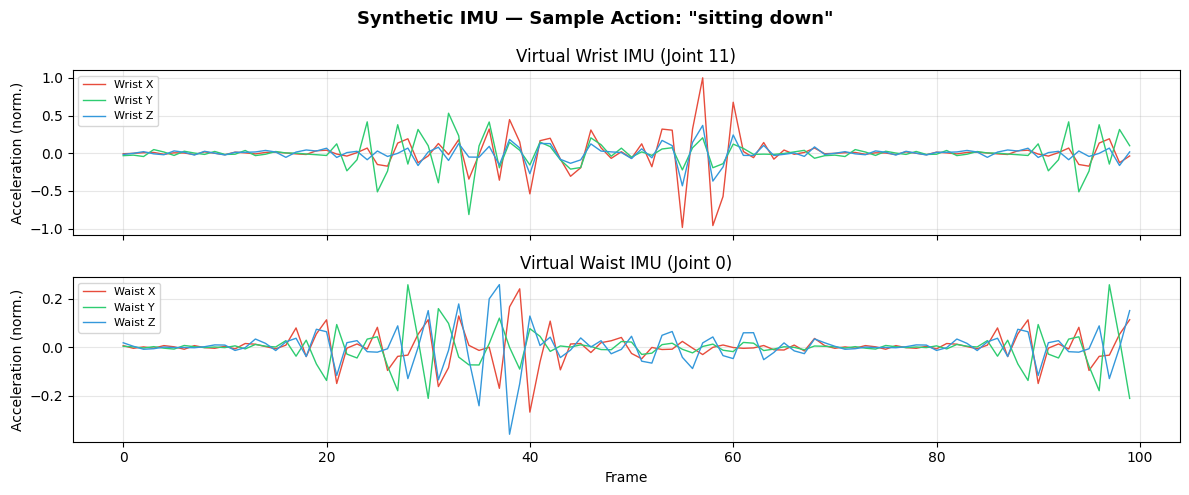

In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 10})

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
t = np.arange(100)
labels_ax = ['X', 'Y', 'Z']
colors = ['#e74c3c', '#2ecc71', '#3498db']

for i in range(3):
    axes[0].plot(t, imu_test[:, i], color=colors[i], label=f'Wrist {labels_ax[i]}', linewidth=1)
    axes[1].plot(t, imu_test[:, 3+i], color=colors[i], label=f'Waist {labels_ax[i]}', linewidth=1)

axes[0].set_title('Virtual Wrist IMU (Joint 11)'); axes[0].legend(fontsize=8)
axes[0].set_ylabel('Acceleration (norm.)'); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Virtual Waist IMU (Joint 0)'); axes[1].legend(fontsize=8)
axes[1].set_ylabel('Acceleration (norm.)'); axes[1].set_xlabel('Frame')
axes[1].grid(True, alpha=0.3)

action_name = MEDICAL_LABELS[MEDICAL_CLASS_MAP[medical_3d[0][0]['label']]]
plt.suptitle(f'Synthetic IMU — Sample Action: "{action_name}"', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/synthetic_imu_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Build Multimodal Dataset

In [9]:
print('Building multimodal dataset (skeleton + synthetic IMU)...')
t0 = time.time()

mm_train_skel, mm_train_imu, mm_train_y = [], [], []
mm_test_skel, mm_test_imu, mm_test_y = [], [], []

train_dirs_set = set(split_info['xsub_train'])
test_dirs_set = set(split_info['xsub_val'])

for ann_2d, ann_3d_item in medical_3d:
    skel = preprocess(ann_2d)  # (2, 100, 17, 3)
    imu = generate_imu_features(ann_3d_item)  # (100, 6)
    label = MEDICAL_CLASS_MAP[ann_2d['label']]

    if ann_2d['frame_dir'] in train_dirs_set:
        mm_train_skel.append(skel)
        mm_train_imu.append(imu)
        mm_train_y.append(label)
    elif ann_2d['frame_dir'] in test_dirs_set:
        mm_test_skel.append(skel)
        mm_test_imu.append(imu)
        mm_test_y.append(label)

mm_train_skel = np.stack(mm_train_skel).astype(np.float32)
mm_train_imu = np.stack(mm_train_imu).astype(np.float32)
mm_train_y = np.array(mm_train_y, dtype=np.int64)
mm_test_skel = np.stack(mm_test_skel).astype(np.float32)
mm_test_imu = np.stack(mm_test_imu).astype(np.float32)
mm_test_y = np.array(mm_test_y, dtype=np.int64)

print(f'Multimodal Train: skel={mm_train_skel.shape} imu={mm_train_imu.shape}')
print(f'Multimodal Test:  skel={mm_test_skel.shape} imu={mm_test_imu.shape}')
print(f'Built in {time.time()-t0:.1f}s')

# Class distribution
from collections import Counter
dist = Counter(mm_train_y.tolist())
for cls_id in range(NUM_CLASSES):
    print(f'  {MEDICAL_LABELS[cls_id]:<20s}: {dist.get(cls_id, 0):>4d}')

# Loaders
mm_train_loader = DataLoader(
    TensorDataset(torch.from_numpy(mm_train_skel),
                  torch.from_numpy(mm_train_imu),
                  torch.from_numpy(mm_train_y)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
mm_test_loader = DataLoader(
    TensorDataset(torch.from_numpy(mm_test_skel),
                  torch.from_numpy(mm_test_imu),
                  torch.from_numpy(mm_test_y)),
    batch_size=128)

# Skeleton-only loaders (same data, no IMU)
skel_train_loader = DataLoader(
    TensorDataset(torch.from_numpy(mm_train_skel), torch.from_numpy(mm_train_y)),
    batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
skel_test_loader = DataLoader(
    TensorDataset(torch.from_numpy(mm_test_skel), torch.from_numpy(mm_test_y)),
    batch_size=128)
print('Loaders ready ✓')

Building multimodal dataset (skeleton + synthetic IMU)...
Multimodal Train: skel=(6695, 2, 100, 17, 3) imu=(6695, 100, 6)
Multimodal Test:  skel=(2749, 2, 100, 17, 3) imu=(2749, 100, 6)
Built in 14.2s
  falling             :  671
  staggering          :  671
  touch head          :  670
  touch chest         :  671
  touch back          :  672
  touch neck          :  672
  nausea              :  671
  standing up         :  663
  sitting down        :  668
  walking towards     :  666
Loaders ready ✓


## 5. Late Fusion Model

**Architecture:**
```
Skeleton (N, 2, 100, 17, 3) → STGCN++ → 256-d feature
IMU      (N, 100, 6)        → 1D-CNN  → 128-d feature
                               ↓ concat
                         FC(384, 10) → logits
```

In [10]:
class IMUEncoder(nn.Module):
    """Simple 1D-CNN for IMU time series. Input: (N, T, C_imu) → (N, feat_dim)."""
    def __init__(self, in_channels=6, feat_dim=128):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(True),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(True),
            nn.AdaptiveAvgPool1d(1),
        )
        self.fc = nn.Linear(128, feat_dim)

    def forward(self, x):
        # x: (N, T, C) → (N, C, T) for Conv1d
        x = x.permute(0, 2, 1)
        x = self.conv(x).squeeze(-1)  # (N, 128)
        return self.fc(x)  # (N, feat_dim)


class LateFusionModel(nn.Module):
    """STGCN++ skeleton encoder + IMU encoder → concat → classifier."""
    def __init__(self, num_classes=10, imu_channels=6, imu_feat=128, **stgcn_kwargs):
        super().__init__()
        self.skeleton_enc = STGCN(num_classes=num_classes, **stgcn_kwargs)
        self.skeleton_feat_dim = self.skeleton_enc.out_channels
        # Remove skeleton FC (we'll use our own fusion FC)
        self.skeleton_enc.fc = nn.Identity()
        self.imu_enc = IMUEncoder(in_channels=imu_channels, feat_dim=imu_feat)
        self.classifier = nn.Linear(self.skeleton_feat_dim + imu_feat, num_classes)
        nn.init.normal_(self.classifier.weight, 0, math.sqrt(2.0/num_classes))
        nn.init.zeros_(self.classifier.bias)

    def forward(self, skel, imu):
        skel_feat = self.skeleton_enc.get_features(skel)  # (N, 256)
        imu_feat = self.imu_enc(imu)  # (N, 128)
        fused = torch.cat([skel_feat, imu_feat], dim=1)  # (N, 384)
        return self.classifier(fused)

_lf = LateFusionModel(NUM_CLASSES, imu_channels=6, imu_feat=128, in_channels=3, **MODEL_KWARGS)
print(f'Late Fusion params: {count_params(_lf):,}')
print(f'  Skeleton encoder: {count_params(_lf.skeleton_enc):,}')
print(f'  IMU encoder:      {count_params(_lf.imu_enc):,}')
print(f'  Classifier:       {count_params(_lf.classifier):,}')
del _lf

Late Fusion params: 505,238
  Skeleton encoder: 440,652
  IMU encoder:      60,736
  Classifier:       3,850


## 6. Training: Skeleton-Only vs Late Fusion

Both trained centralized for 10 epochs with identical optimizer (SGD, lr=0.01).

In [11]:
%%time
print('Training skeleton-only (centralized, 10 epochs)...')
skel_model = build_model(NUM_CLASSES, 3, **MODEL_KWARGS)
skel_model.to(DEVICE)
opt = torch.optim.SGD(skel_model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[6, 8], gamma=0.1)
crit = nn.CrossEntropyLoss()

skel_history = []
for ep in range(1, QUICK_EPOCHS+1):
    skel_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for xb, yb in skel_train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); logits = skel_model(xb)
        loss = crit(logits, yb); loss.backward(); opt.step()
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0); running_loss += loss.item() * yb.size(0)
    sched.step()
    test_acc = evaluate(skel_model, skel_test_loader, DEVICE)
    skel_history.append({'epoch': ep, 'train_acc': correct/total,
                         'train_loss': running_loss/total, 'test_acc': float(test_acc)})
    print(f'  Epoch {ep:2d}/{QUICK_EPOCHS} train={correct/total:.4f} loss={running_loss/total:.4f} test={test_acc:.4f}')

skel_best = max(h['test_acc'] for h in skel_history)
print(f'\n✓ Skeleton-only — Best: {skel_best:.4f}')
skel_model.cpu(); torch.cuda.empty_cache()

Training skeleton-only (centralized, 10 epochs)...
  Epoch  1/10 train=0.2898 loss=2.1013 test=0.3427
  Epoch  2/10 train=0.4530 loss=1.4120 test=0.3660
  Epoch  3/10 train=0.5819 loss=1.0512 test=0.6089
  Epoch  4/10 train=0.6953 loss=0.8092 test=0.6573
  Epoch  5/10 train=0.7843 loss=0.5922 test=0.7825
  Epoch  6/10 train=0.8114 loss=0.5008 test=0.7232
  Epoch  7/10 train=0.8618 loss=0.3789 test=0.7930
  Epoch  8/10 train=0.8726 loss=0.3436 test=0.7930
  Epoch  9/10 train=0.8762 loss=0.3411 test=0.7792
  Epoch 10/10 train=0.8798 loss=0.3301 test=0.7850

✓ Skeleton-only — Best: 0.7930
CPU times: user 9min 7s, sys: 18.9 s, total: 9min 26s
Wall time: 9min 31s


In [12]:
%%time
print('Training Late Fusion (skeleton + IMU, 10 epochs)...')
fusion_model = LateFusionModel(NUM_CLASSES, imu_channels=6, imu_feat=128,
                                in_channels=3, **MODEL_KWARGS)
fusion_model.to(DEVICE)
opt = torch.optim.SGD(fusion_model.parameters(), lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.MultiStepLR(opt, milestones=[6, 8], gamma=0.1)
crit = nn.CrossEntropyLoss()

fusion_history = []
for ep in range(1, QUICK_EPOCHS+1):
    fusion_model.train()
    correct, total, running_loss = 0, 0, 0.0
    for skel_b, imu_b, yb in mm_train_loader:
        skel_b, imu_b, yb = skel_b.to(DEVICE), imu_b.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        logits = fusion_model(skel_b, imu_b)
        loss = crit(logits, yb); loss.backward(); opt.step()
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0); running_loss += loss.item() * yb.size(0)
    sched.step()
    # Evaluate
    fusion_model.eval()
    fc, ft = 0, 0
    with torch.no_grad():
        for skel_b, imu_b, yb in mm_test_loader:
            skel_b, imu_b, yb = skel_b.to(DEVICE), imu_b.to(DEVICE), yb.to(DEVICE)
            logits = fusion_model(skel_b, imu_b)
            fc += (logits.argmax(1) == yb).sum().item(); ft += yb.size(0)
    test_acc = fc / ft
    fusion_history.append({'epoch': ep, 'train_acc': correct/total,
                           'train_loss': running_loss/total, 'test_acc': float(test_acc)})
    print(f'  Epoch {ep:2d}/{QUICK_EPOCHS} train={correct/total:.4f} loss={running_loss/total:.4f} test={test_acc:.4f}')

fusion_best = max(h['test_acc'] for h in fusion_history)
print(f'\n✓ Late Fusion — Best: {fusion_best:.4f}')
fusion_model.cpu(); torch.cuda.empty_cache()

Training Late Fusion (skeleton + IMU, 10 epochs)...
  Epoch  1/10 train=0.3911 loss=1.8896 test=0.3045
  Epoch  2/10 train=0.6986 loss=0.8175 test=0.5537
  Epoch  3/10 train=0.8205 loss=0.4870 test=0.5209
  Epoch  4/10 train=0.8717 loss=0.3499 test=0.6981
  Epoch  5/10 train=0.8825 loss=0.3061 test=0.6250
  Epoch  6/10 train=0.9014 loss=0.2631 test=0.7730
  Epoch  7/10 train=0.9405 loss=0.1796 test=0.7679
  Epoch  8/10 train=0.9488 loss=0.1555 test=0.7628
  Epoch  9/10 train=0.9545 loss=0.1465 test=0.7490
  Epoch 10/10 train=0.9506 loss=0.1464 test=0.7425

✓ Late Fusion — Best: 0.7730
CPU times: user 9min 1s, sys: 26 s, total: 9min 27s
Wall time: 9min 30s


## 7. Results Comparison

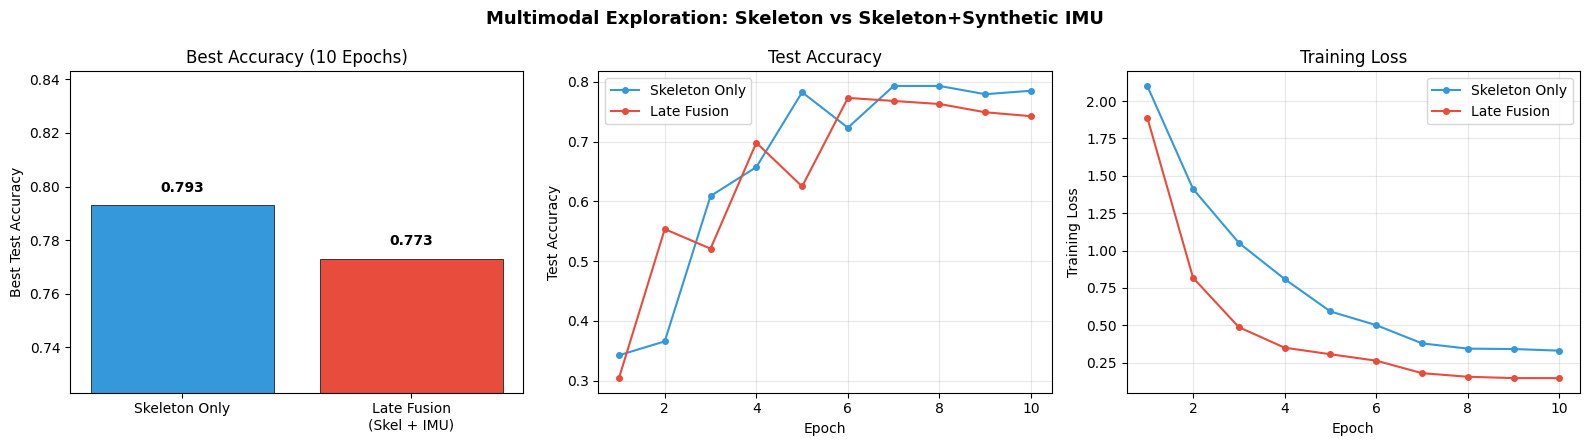


Skeleton Only: 0.7930
Late Fusion:   0.7730
Delta:         -0.0200 (-2.0 pp)
→ Synthetic IMU did not help — consider real IMU data (UTD-MHAD) or Fusion-GCN approach


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Panel 1: Bar chart
methods_mm = ['Skeleton Only', 'Late Fusion\n(Skel + IMU)']
accs_mm = [skel_best, fusion_best]
colors_mm = ['#3498db', '#e74c3c']
bars = axes[0].bar(methods_mm, accs_mm, color=colors_mm, edgecolor='k', linewidth=0.5)
axes[0].set_ylabel('Best Test Accuracy')
axes[0].set_title(f'Best Accuracy ({QUICK_EPOCHS} Epochs)')
axes[0].set_ylim(min(accs_mm)-0.05, max(accs_mm)+0.05)
for bar, acc in zip(bars, accs_mm):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{acc:.3f}', ha='center', fontweight='bold')

# Panel 2: Test accuracy curves
axes[1].plot([h['epoch'] for h in skel_history], [h['test_acc'] for h in skel_history],
             '-o', color='#3498db', label='Skeleton Only', linewidth=1.5, markersize=4)
axes[1].plot([h['epoch'] for h in fusion_history], [h['test_acc'] for h in fusion_history],
             '-o', color='#e74c3c', label='Late Fusion', linewidth=1.5, markersize=4)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Test Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Panel 3: Training loss curves
axes[2].plot([h['epoch'] for h in skel_history], [h['train_loss'] for h in skel_history],
             '-o', color='#3498db', label='Skeleton Only', linewidth=1.5, markersize=4)
axes[2].plot([h['epoch'] for h in fusion_history], [h['train_loss'] for h in fusion_history],
             '-o', color='#e74c3c', label='Late Fusion', linewidth=1.5, markersize=4)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Training Loss')
axes[2].set_title('Training Loss'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Multimodal Exploration: Skeleton vs Skeleton+Synthetic IMU',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/multimodal_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

delta = fusion_best - skel_best
print(f'\nSkeleton Only: {skel_best:.4f}')
print(f'Late Fusion:   {fusion_best:.4f}')
print(f'Delta:         {delta:+.4f} ({delta*100:+.1f} pp)')
if delta > 0:
    print('→ Synthetic IMU IMPROVED accuracy — worth pursuing further (Fusion-GCN, real IMU)')
else:
    print('→ Synthetic IMU did not help — consider real IMU data (UTD-MHAD) or Fusion-GCN approach')

In [15]:
results = {
    'experiment': 'multimodal_exploration',
    'date': time.strftime('%Y-%m-%d %H:%M'),
    'config': {
        'seed': SEED, 'quick_epochs': QUICK_EPOCHS, 'lr': LR,
        'imu_joints': {k: v for k, v in IMU_JOINTS.items()},
        'imu_channels': 6,
        'fusion_type': 'late_fusion',
        'skeleton_feat_dim': 256, 'imu_feat_dim': 128,
    },
    'data': {
        'train_samples': len(mm_train_y),
        'test_samples': len(mm_test_y),
        'num_classes': NUM_CLASSES,
    },
    'results': {
        'skeleton_only': {'history': skel_history, 'best_acc': skel_best},
        'late_fusion':   {'history': fusion_history, 'best_acc': fusion_best},
        'delta_pp': round((fusion_best - skel_best) * 100, 2),
    },
}
with open('outputs/multimodal_scan.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Saved: outputs/multimodal_scan.json')

# Copy to Drive
try:
    import shutil
    from google.colab import drive
    drive.mount('/content/drive')
    dst = '/content/drive/MyDrive/demo1_multimodal'
    os.makedirs(dst, exist_ok=True)
    for fn in ['outputs/multimodal_scan.json', 'outputs/multimodal_comparison.png',
               'outputs/synthetic_imu_sample.png']:
        if os.path.exists(fn): shutil.copy2(fn, dst)
    print(f'Copied to Drive: {dst}')
except Exception as e:
    print(f'Drive mount skipped ({e})')

Saved: outputs/multimodal_scan.json
Mounted at /content/drive
Copied to Drive: /content/drive/MyDrive/demo1_multimodal


## 8. Summary & Next Steps

### Results

| Model | Best Test Acc | Params | Notes |
|-------|--------------|--------|-------|
| Skeleton Only (STGCN++) | `skel_best` | ~443K | Baseline |
| Late Fusion (STGCN++ + 1D-CNN) | `fusion_best` | ~500K | +50K IMU encoder |

### If Improvement Observed
1. **Fusion-GCN**: Add IMU as extra channels/nodes in STGCN++ graph (reported +12% F1)
2. **Add more virtual sensors**: ankles (joints 15, 19), left wrist (joint 7) → 12+ channels
3. **Combine with FL**: Run best FL method (from other notebook) with fusion model
4. **Real IMU validation**: Download UTD-MHAD for comparison against synthetic

### If No Improvement
1. Synthetic IMU may be too similar to skeleton (redundant information)
2. Try **real IMU**: UTD-MHAD (direct download) or SmartFallMM (GitHub)
3. Try **Fusion-GCN** instead of late fusion — tighter integration may extract complementary info
4. Focus on FL methods (other notebook) as primary research direction